# 06 — Discount Impact on Profit Margins
Quantify how increasing discount bands erode profit margins across all product categories.

## Setup — Spark Session & Load HDFS Tables

In [1]:
import os, sys

os.environ["JAVA_HOME"]             = "/usr/local/java"
os.environ["SPARK_HOME"]            = "/usr/local/spark"
os.environ["HADOOP_CONF_DIR"]       = "/usr/local/hadoop/etc/hadoop"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
        .appName("06 — Discount Impact on Profit Margins")
        .master("spark://namenode:7077")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

HDFS_BASE = "hdfs:///data"

def load_csv(name, renames):
    df = (spark.read
          .option("header", "true")
          .option("inferSchema", "true")
          .csv(f"{HDFS_BASE}/{name}.csv"))
    for old, new in renames.items():
        df = df.withColumnRenamed(old, new)
    df.createOrReplaceTempView(name)
    return df

load_csv("customers",   {"Customer ID":"customer_id","Customer Name":"customer_name","Segment":"segment"})
load_csv("orders",      {"Order ID":"order_id","Order Date":"order_date","Ship Date":"ship_date",
                          "Ship Mode":"ship_mode","Customer ID":"customer_id","Postal Code":"postal_code"})
load_csv("order_items", {"Row ID":"row_id","Order ID":"order_id","Product ID":"product_id",
                          "Sales":"sales","Quantity":"quantity","Discount":"discount","Profit":"profit"})
load_csv("products",    {"Product ID":"product_id","Product Name":"product_name",
                          "Category":"category","Sub-Category":"sub_category"})
load_csv("locations",   {"Postal Code":"postal_code","City":"city","State":"state",
                          "Country":"country","Region":"region"})

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CHARTS_DIR = "/usr/local/hadoop/etc/hadoop/assessment-2/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)
print("Ready.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 17:01:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Ready.


## Query

In [2]:
df = spark.sql('''
    SELECT
        CASE
            WHEN oi.discount = 0         THEN "0% None"
            WHEN oi.discount <= 0.10     THEN "1-10%"
            WHEN oi.discount <= 0.20     THEN "11-20%"
            WHEN oi.discount <= 0.30     THEN "21-30%"
            WHEN oi.discount <= 0.50     THEN "31-50%"
            ELSE                              ">50%"
        END AS discount_band,
        p.category,
        ROUND(AVG(oi.profit / oi.sales)*100, 2) AS avg_margin_pct,
        COUNT(*) AS transactions
    FROM order_items oi JOIN products p ON oi.product_id = p.product_id
    WHERE oi.sales > 0
    GROUP BY discount_band, p.category ORDER BY discount_band
''').toPandas()

summary = spark.sql('''
    SELECT
        CASE
            WHEN oi.discount = 0     THEN "0% None"
            WHEN oi.discount <= 0.10 THEN "1-10%"
            WHEN oi.discount <= 0.20 THEN "11-20%"
            WHEN oi.discount <= 0.30 THEN "21-30%"
            WHEN oi.discount <= 0.50 THEN "31-50%"
            ELSE                          ">50%"
        END AS discount_band,
        ROUND(AVG(oi.profit / oi.sales)*100, 2) AS avg_margin_pct,
        COUNT(*) AS transactions
    FROM order_items oi WHERE oi.sales > 0
    GROUP BY discount_band ORDER BY discount_band
''').toPandas()
print(summary)

  discount_band  avg_margin_pct  transactions
0       0% None           34.02          4798
1         1-10%           15.58            94
2        11-20%           17.48          3709
3        21-30%          -11.55           227
4        31-50%          -29.61           310
5          >50%         -113.88           856


## Visualisation

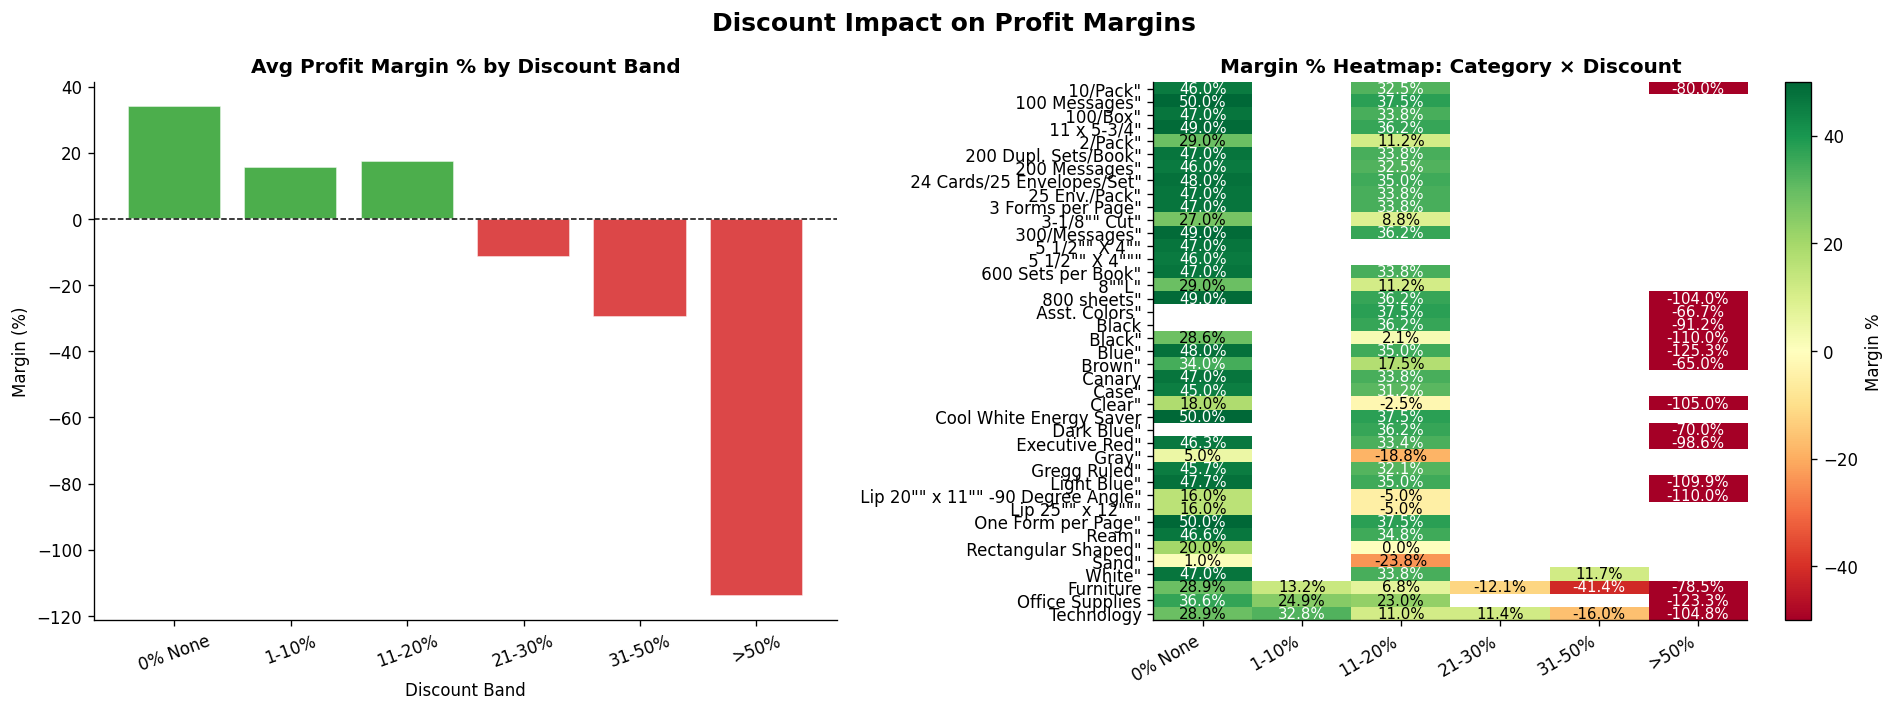

Chart saved to /usr/local/hadoop/etc/hadoop/assessment-2/charts/06_discount_impact.png


In [3]:
band_order = ["0% None","1-10%","11-20%","21-30%","31-50%",">50%"]
summary["discount_band"] = pd.Categorical(summary["discount_band"], categories=band_order, ordered=True)
summary = summary.sort_values("discount_band")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bar_c = ["#2ca02c" if v >= 0 else "#d62728" for v in summary["avg_margin_pct"]]
axes[0].bar(summary["discount_band"], summary["avg_margin_pct"], color=bar_c, alpha=0.85, edgecolor="white")
axes[0].axhline(0, color="black", lw=0.9, ls="--")
axes[0].set_title("Avg Profit Margin % by Discount Band", fontweight="bold")
axes[0].set_xlabel("Discount Band"); axes[0].set_ylabel("Margin (%)")
axes[0].tick_params(axis="x", rotation=20)

pivot = df.pivot_table(index="category", columns="discount_band", values="avg_margin_pct")
pivot = pivot.reindex(columns=[c for c in band_order if c in pivot.columns])
im = axes[1].imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=-50, vmax=50)
axes[1].set_xticks(range(len(pivot.columns))); axes[1].set_xticklabels(pivot.columns, rotation=30, ha="right")
axes[1].set_yticks(range(len(pivot.index)));  axes[1].set_yticklabels(pivot.index)
axes[1].set_title("Margin % Heatmap: Category × Discount", fontweight="bold")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            axes[1].text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=9,
                         color="white" if abs(val) > 30 else "black")
plt.colorbar(im, ax=axes[1], label="Margin %")
plt.suptitle("Discount Impact on Profit Margins", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{CHARTS_DIR}/06_discount_impact.png", bbox_inches="tight")
plt.show()
print(f"Chart saved to {CHARTS_DIR}/06_discount_impact.png")

## Stop Spark

In [4]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
